### BNN classification, ORDINAL target variable, example (red wine dataset)

<b>Small update: ROC-AUC -score added in metrics</b>

In [1]:
# installations:
# pip install torch
# pip install torchbnn

# REMEMBER: GPU is actually slower in BNN training (unless using Pyro-module or something else)

import torch
import torch.nn as nn
import torch.optim as optim
import torchbnn as bnn
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import random
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.calibration import calibration_curve
from sklearn.metrics import roc_auc_score



/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/torch/utils/_pytree.py:185: FutureWarning: optree is installed but the version is too old to support PyTorch Dynamo in C++ pytree. C++ pytree support is disabled. Please consider upgrading optree using `python3 -m pip install --upgrade 'optree>=0.13.0'`.
  warnings.warn(


### Load, process and optimize your data in this part

In [2]:
# Load dataset
df = pd.read_csv("Housing_Prices.csv")

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             21613 non-null  int64  
 1   date           21613 non-null  object 
 2   price          21613 non-null  float64
 3   bedrooms       21613 non-null  int64  
 4   bathrooms      21613 non-null  float64
 5   sqft_living    21613 non-null  int64  
 6   sqft_lot       21613 non-null  int64  
 7   floors         21613 non-null  float64
 8   waterfront     21613 non-null  int64  
 9   view           21613 non-null  int64  
 10  condition      21613 non-null  int64  
 11  grade          21613 non-null  int64  
 12  sqft_above     21613 non-null  int64  
 13  sqft_basement  21613 non-null  int64  
 14  yr_built       21613 non-null  int64  
 15  yr_renovated   21613 non-null  int64  
 16  zipcode        21613 non-null  int64  
 17  lat            21613 non-null  float64
 18  long  

In [4]:
# Check for nans
df.isnull().sum()

id               0
date             0
price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
grade            0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
zipcode          0
lat              0
long             0
sqft_living15    0
sqft_lot15       0
dtype: int64

In [5]:

target_variable = "price"

In [6]:
# everything is already numeric, we can just proceed with the BNN
df.head(5)

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7229300521,20141013T000000,231300.0,2,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


In [7]:
# There is some irrelevent colums that we do not need int his case, I am going to drop here.
df = df.drop(["id", "date","zipcode","lat", "long"], axis=1)

In [8]:
# Here i am getting error 
# IndexError: Target 2630 is out of bounds.
# I tried some time to fix with google and also with the help of ChatGPT and I found this solution

# df["price_bin"] = pd.qcut(df["price"], q=10, labels=False)
# With this I am able to solve this issue and heading towards next code..
# but with this I got another new colum with the name of price_bin, along with price bins concept

# I will share next results and my finding with experiements 

In [9]:
# Bin the price into 10 classes for classification
df["price_bin"] = pd.qcut(df["price"], q=10, labels=False)


In [10]:
target_variable = "price_bin"


### X/y, train/test/val -split etc

In [11]:
# With quick fix 
# I used Counter to count samples per class.
# I removed all samples where the class occurs fewer than 2 times.
#Then, train_test_split(..., stratify=y) can proceed safely.

In [12]:

# i was getting errors 
# ValueError: The least populated class in y has only 1 member, which is too few. The minimum number of groups for any class cannot be less ...
# Then Target 2630 is out of bounds.
# Then I need to change code according to bins along with following approaches 

# 1- Target Column
#  Uses original price column (continuous numeric) and now Uses price_bin (discretized into classes)
# 2- Task Type
# ries to treat regression target (price) as classification — which causes errors So I solve it by Properly turns regression into classification via binning, then handles class issues

# 3- Class Count Handling
# Does not check for rare classes → may include classes with only one sample (leads to error) and now its Removes any class that appears only once using Counter

# 3- Error Handling
# Prone to errors like IndexError: Target 2630 is out of bounds. and now Explicitly avoids such errors by dropping rare classes before training  

# With these changing now code is working fine and removed all erros and I am commenting below example code that I got from teacher's notbook. Obviously that is base unserstanding and helped alot to me for doing this task


from sklearn.preprocessing import LabelEncoder
from collections import Counter
import numpy as np

target_variable = "price_bin"  # replace with actual if different

# Encode the target (price) to class labels: 0, 1, 2, ...
le = LabelEncoder()
df[target_variable] = le.fit_transform(df[target_variable])
y = df[target_variable].values
X = df.drop(columns=[target_variable]).values

# ✅ Remove rare classes (with only 1 instance)
class_counts = Counter(y)
valid_classes = [cls for cls, count in class_counts.items() if count > 1]
valid_indices = [i for i, label in enumerate(y) if label in valid_classes]

X = X[valid_indices]
y = y[valid_indices]

# Normalize features
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_test, y_test, test_size=0.5, random_state=42)

# Convert to tensors
X_train = torch.tensor(X_train, dtype=torch.float32)
X_val = torch.tensor(X_val, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)

y_train = torch.tensor(y_train, dtype=torch.long)
y_val = torch.tensor(y_val, dtype=torch.long)
y_test = torch.tensor(y_test, dtype=torch.long)

# DataLoaders
train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=64, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val, y_val), batch_size=64, shuffle=False)
test_loader = DataLoader(TensorDataset(X_test, y_test), batch_size=64, shuffle=False)


In [13]:
# from sklearn.preprocessing import OneHotEncoder, LabelEncoder

# # get unique values in target variable
# categories = list(np.unique(df[target_variable]))

# # Split features and target
# X = df.drop(columns=[target_variable]).values
# y = df[target_variable].values

# # let's encode our target from the original, eg. 3,4,5,6,7,8 to 0,1,2,3,4,5
# le = LabelEncoder()
# y = le.fit_transform(y)

# # if bad result, consider shuffling the dataset just in case
# # normalize variables
# scaler = StandardScaler()
# X = scaler.fit_transform(X)

# # train/test, 80% for training, remaining 20% for test/val
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y)

# # split into test and validation (50% in half)
# X_val, X_test, y_val, y_test = train_test_split(X_test, y_test, test_size=0.5, random_state=42)

# # convert to PyTorch tensor format
# X_train, X_test, X_val = torch.tensor(X_train, dtype=torch.float32), torch.tensor(X_test, dtype=torch.float32), torch.tensor(X_val, dtype=torch.float32)
# y_train, y_test, y_val = torch.tensor(y_train, dtype=torch.long), torch.tensor(y_test, dtype=torch.long), torch.tensor(y_val, dtype=torch.long) 

# # create PyTorch dataloaders, YOU CAN ADJUST THE BATCH SIZES IF YOU WISH
# # basic rule: bigger batch size => faster training, but more memory needed
# # only shuffle the training dataset, NEVER SHUFFLE TEST/VAL
# train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=64, shuffle=True)
# test_loader = DataLoader(TensorDataset(X_test, y_test), batch_size=64, shuffle=False)
# val_loader = DataLoader(TensorDataset(X_val, y_val), batch_size=64, shuffle=False)


### Hyperparameters and other configurables for the BNN

In [14]:
# all common hyperparameters we can finetune in the future

# sigma = standard deviation of the noise term (this is often optimized)
# if model is too confident and OVERFITS at the same time, INCREASE sigma
# if predictions are too noisy, too much variation or uncertain  => DECREASE sigma
# COMMON VALUES 0.1 - 0.5

# lambda_kl = amount of KL in the loss function => regularization parameter to avoid OVERFITTING
# if model overfits => increase, if model underfits => decrease
# COMMON VALUES 0.0+ - 0.2

# mu = mean of distribution (you can usually use the defaul 0 in classification)
# if model overfits => decrease mu
# if model underfits => increase mu
# mu = 0 => in the middle of standard distribution (range -3 to +3) => this needs be checked!
# COMMON VALUES: usually 0 in classification

# mc_samples_eval = monte carlo sample size used to approximate distributions in weights
# more samples used => more accurate uncertainty estimation (but heavier to compute)
# if uncertainty is not optimal, try increasing mc_sample -size a little bit
# if model training is too heavy or underfits, you can decrease the sample size
# COMMON VALUES: 25 - 200

mu = 0
sigma = 0.4
lambda_kl = 0.1
mc_samples_eval = 50

# remember to adjust the BNN network structure in the below cell if needed
# amount of layers, layer sizes, amount of dropout regularization etc.

# learning rate is same as in ANN => controls the aggressiveness of optimization
# too large value => model overshoots optimization attempts
# too small value => model learns too slowly
# COMMON VALUES similar to ANN learning rates, small values (0.03 or less), usually 0.1 or less
bnn_learning_rate = 0.001

# weight_decay = regularization applied to model weights (probability distributions)
# penalizes large weights IN ORDER to prevent OVERFITTING
# if model overfits => you can try increasing weight decay, if underfits => try decreasing
# COMMON VALUES are usually quite small, 0.0001 to 0.0005
bnn_weight_decay = 0.0001

### Define Bayesian Neural Network for PyTorch

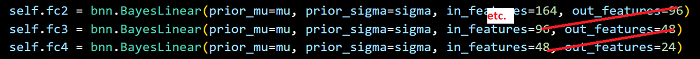

In [15]:
# Bayesian Neural Network -model (BNN) with deeper layers and Monte-Carlo dropout
class BayesianNN(nn.Module):
    def __init__(self, input_dim, output_dim, mu=0, sigma=0.5):
        super().__init__()
        # DEFINE ALL LAYERS THAT WILL BE COMBINED INTO ONE MODEL IN forward()
        # NOTE: Torch requires as to "chain" connected layer => out_features and in_features have to match in connected layers
        # for example "in_features=96, out_features=48" means that previous layers to have out_features of 96
        # and the next layer has to have in features of 48
        self.fc1 = bnn.BayesLinear(prior_mu=mu, prior_sigma=sigma, in_features=input_dim, out_features=128)
        self.fc2 = bnn.BayesLinear(prior_mu=mu, prior_sigma=sigma, in_features=128, out_features=64)
        self.fc3 = bnn.BayesLinear(prior_mu=mu, prior_sigma=sigma, in_features=64, out_features=32)
        self.fc4 = bnn.BayesLinear(prior_mu=mu, prior_sigma=sigma, in_features=32, out_features=16)
        self.fc5 = bnn.BayesLinear(prior_mu=mu, prior_sigma=sigma, in_features=16, out_features=output_dim)
        self.relu = nn.ReLU()

        # adjust dropout rate to increase regularization
        self.dropout = nn.Dropout(0.3)  

        # THE BATCH NORMALIZATION SIZES HAVE THE MATCH THE OUTPUT OF THE CORRESPONDING LAYER
        self.batch_norm1 = nn.BatchNorm1d(128)
        self.batch_norm2 = nn.BatchNorm1d(64)
        self.batch_norm3 = nn.BatchNorm1d(32)
        self.batch_norm4 = nn.BatchNorm1d(16)
    
    # "forward pass", if mc_dropout = True => adds a dropout layer between the BayesLinear -layers
    def forward(self, x, mc_dropout=False):
        # NOTE: batch normalization helps in stabilizing the training process
        x = self.batch_norm1(self.relu(self.fc1(x))) 
        x = self.dropout(x) if mc_dropout else x
        x = self.batch_norm2(self.relu(self.fc2(x)))
        x = self.dropout(x) if mc_dropout else x
        x = self.batch_norm3(self.relu(self.fc3(x)))
        x = self.dropout(x) if mc_dropout else x
        x = self.batch_norm4(self.relu(self.fc4(x)))
        x = self.dropout(x) if mc_dropout else x
        return self.fc5(x)

### Hyperparameters and model initialization

In [16]:
# model, loss, optimizer
model = BayesianNN(input_dim=X.shape[1], 
                   output_dim=len(np.unique(y)),
                   sigma=sigma,
                   mu=mu
                   )

# Loss function for multi-class classification
criterion = nn.CrossEntropyLoss() 

# Bayesian KL Divergence Loss (efficient regularization for BNN)
bkl_loss = bnn.BKLLoss(reduction='mean')  

# AdamW is common in BNN
optimizer = optim.AdamW(model.parameters(), lr=bnn_learning_rate, weight_decay=bnn_weight_decay)

### Create train/evaluate -functions for BNN training/evaluation

In [17]:
# evaluate function with uncertainty estimation
def evaluate(model, loader, mc_samples=mc_samples_eval):
    # set model to evaluation mode
    model.eval() 
    total_correct = 0
    total_samples = 0
    total_loss = 0
    uncertainties = []

    # disable gradient updates during evaluation
    with torch.no_grad():
        for X_batch, y_batch in loader:
            outputs_list = [model(X_batch, mc_dropout=True) for _ in range(mc_samples)]
            outputs_stack = torch.stack(outputs_list) 

            # average prediction and standard deviation (uncertainty)
            outputs_mean = outputs_stack.mean(dim=0)  
            outputs_std = outputs_stack.std(dim=0)

            loss = criterion(outputs_mean, y_batch)
            total_loss += loss.item()

            probs = torch.softmax(outputs_mean, dim=1)
            preds = torch.argmax(probs, dim=1)

            total_correct += (preds == y_batch).sum().item()
            total_samples += y_batch.size(0)

            uncertainties.extend(outputs_std.mean(dim=1).cpu().numpy()) 

    # current accuracy, loss and average uncertainty
    accuracy_score = total_correct / total_samples
    nll = total_loss / len(loader) 
    avg_uncertainty = np.mean(uncertainties)  

    print(f"Val Accuracy: {accuracy_score:.4f}, Val loss: {nll:.4f}, Avg. Uncertainty: {avg_uncertainty:.4f}")

    # return per-sample uncertainty if needed
    return accuracy_score, nll, avg_uncertainty, uncertainties  

# training loop with BKLLoss
def train(model, loader, epochs):
    model.train()
    history = {}
    history['train_loss'] = []
    history['val_loss'] = []
    history['val_accuracy'] = []
    history['avg_uncertainty'] = []
    for epoch in range(epochs):
        total_loss = 0
        for X_batch, y_batch in loader:
            optimizer.zero_grad()
            outputs = model(X_batch, mc_dropout=True)
            
            # compute cross-entropy and BKL loss and combine them
            ce_loss = criterion(outputs, y_batch)
            kl_loss = bkl_loss(model)
            loss = ce_loss + lambda_kl * kl_loss
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        print(f"Epoch {epoch+1}/{epochs}, Training Loss: {total_loss/len(loader):.4f}")

        val_accuracy, val_loss, avg_uncertainty, _ = evaluate(model, val_loader)
        history['train_loss'].append(total_loss / len(loader))
        history['val_loss'].append(val_loss)
        history['val_accuracy'].append(val_accuracy)
        history['avg_uncertainty'].append(avg_uncertainty)

        # set model to training mode for next epoch
        model.train()
        
    return history

### TRAIN THE BNN MODEL!

In [18]:
# train the model (fit), epochs are usually 1000-5000 with BNN classification
history = train(model, train_loader, epochs=1500)

Epoch 1/1500, Training Loss: 3.4219
Val Accuracy: 0.1296, Val loss: 2.2728, Avg. Uncertainty: 0.8573
Epoch 2/1500, Training Loss: 2.8993
Val Accuracy: 0.1513, Val loss: 2.2551, Avg. Uncertainty: 0.6657
Epoch 3/1500, Training Loss: 2.6502
Val Accuracy: 0.1365, Val loss: 2.2592, Avg. Uncertainty: 0.5070
Epoch 4/1500, Training Loss: 2.4835
Val Accuracy: 0.1393, Val loss: 2.2541, Avg. Uncertainty: 0.4174
Epoch 5/1500, Training Loss: 2.4041
Val Accuracy: 0.1550, Val loss: 2.2511, Avg. Uncertainty: 0.3463
Epoch 6/1500, Training Loss: 2.3457
Val Accuracy: 0.1569, Val loss: 2.2395, Avg. Uncertainty: 0.3092
Epoch 7/1500, Training Loss: 2.3112
Val Accuracy: 0.1536, Val loss: 2.2425, Avg. Uncertainty: 0.2685
Epoch 8/1500, Training Loss: 2.2978


KeyboardInterrupt: 

### Error metrics

In [ ]:
# get predictions etc. for test data
model.eval()
y_true = y_test.cpu().numpy()
y_pred = []
y_pred_probs = [] 

with torch.no_grad():
    for X_batch, _ in test_loader:
        # get average outputs, average of 10 predictions for each
        outputs_list = [model(X_batch, mc_dropout=True) for _ in range(10)]
        outputs_stack = torch.stack(outputs_list)  
        outputs_mean = outputs_stack.mean(dim=0)  
        preds = torch.argmax(outputs_mean, dim=1)
        probs = torch.softmax(outputs_mean, dim=1)
        y_pred_probs.extend(probs.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())


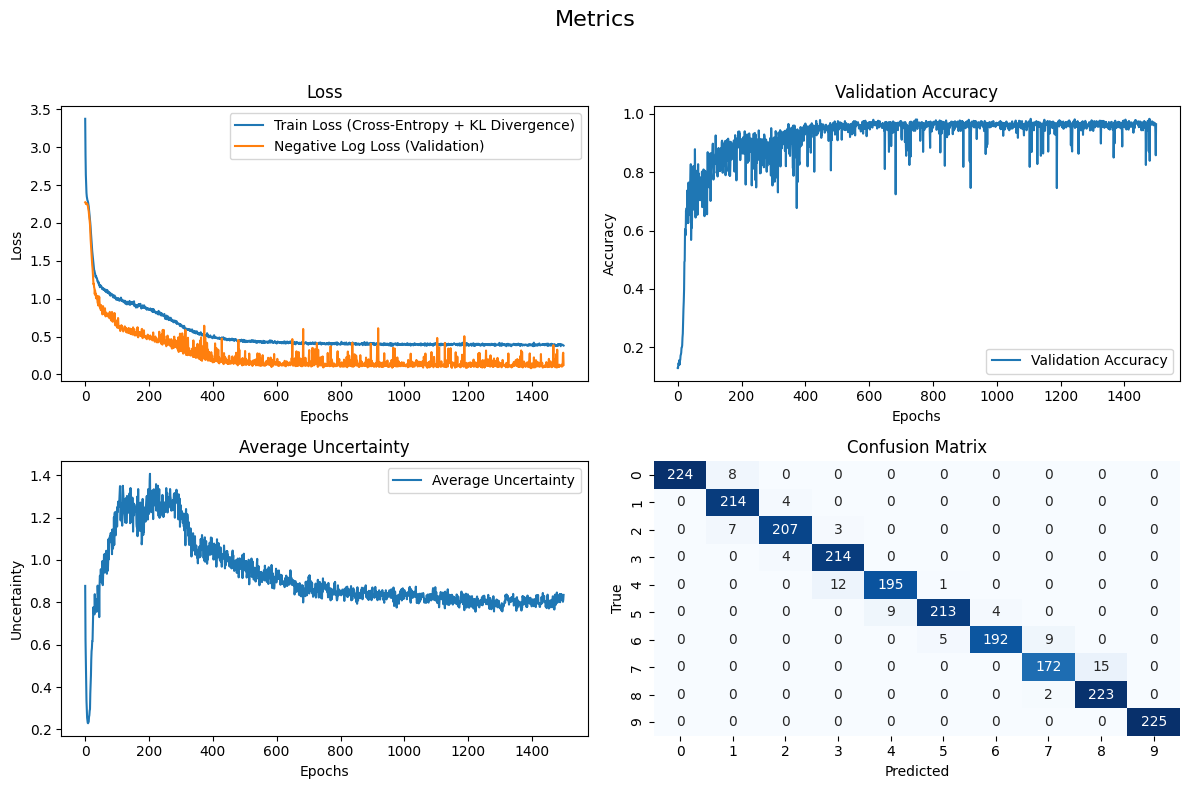

In [ ]:
# plot training history
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
plt.suptitle('Metrics', fontsize=16)

# BNN, losses
axes[0, 0].plot(history['train_loss'], label='Train Loss (Cross-Entropy + KL Divergence)')
axes[0, 0].plot(history['val_loss'], label='Negative Log Loss (Validation)')
axes[0, 0].set_title('Loss')
axes[0, 0].set_xlabel('Epochs')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].legend()

# accuracy
axes[0, 1].plot(history['val_accuracy'], label='Validation Accuracy')
axes[0, 1].set_title('Validation Accuracy')
axes[0, 1].set_xlabel('Epochs')
axes[0, 1].set_ylabel('Accuracy')
axes[0, 1].legend()

# uncertainty
axes[1, 0].plot(history['avg_uncertainty'], label='Average Uncertainty')
axes[1, 0].set_title('Average Uncertainty')
axes[1, 0].set_xlabel('Epochs')
axes[1, 0].set_ylabel('Uncertainty')
axes[1, 0].legend()

# confusion matrix
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1, 1], vmax=cm.max(), cbar=False)
axes[1, 1].set_title('Confusion Matrix')
axes[1, 1].set_xlabel('Predicted')
axes[1, 1].set_ylabel('True')

# combine the four plots into one and show
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

In [ ]:
# Both training and validation loss drop quickly, which is good.
# Validation loss flattens out around epoch 200 and stays low and stable.
# There are some spikes in validation loss maybe because of overconfident but wrong predictions, its just my obvservation
# Low validation loss with convergence = model is learning well. and Smooth training loss = no major overfitting.

# Accuracy starts low and increases rapidly it very good and increasing after around 95–97% after ~200 epochs.
# Very high validation accuracy. Slight noise is expected in Bayesian models due to the outcome was random predictions.

# Starts low (model is not yet confident). Peaks around epoch 200 — model becomes aware of data variance. Gradually drops and stabilizes around 0.8 uncertainty.
# Good to see a peak in uncertainty early and gradually drop implies improved confidence as training progresses.

# Minor mix-ups between close classes (5&6: 213 vs 192+9, 7&8: 15 errors) — expected for similar price bins.

# High accuracy (>96%) and low loss — model fits well with the balanced performance across all 10 classes.No obvious overfitting (loss and accuracy curves align).

# ~96–97% Accuracy on 10-class classification is excellent. Stable training and validation curves.Bayesian uncertainty is well-captured with this experiment and classification mdoel and minimal class confusion.




In [ ]:
# the usual classification report
print(classification_report(y_true, y_pred, zero_division=0.0))

              precision    recall  f1-score   support

           0       1.00      0.97      0.98       232
           1       0.93      0.98      0.96       218
           2       0.96      0.95      0.96       217
           3       0.93      0.98      0.96       218
           4       0.96      0.94      0.95       208
           5       0.97      0.94      0.96       226
           6       0.98      0.93      0.96       206
           7       0.94      0.92      0.93       187
           8       0.94      0.99      0.96       225
           9       1.00      1.00      1.00       225

    accuracy                           0.96      2162
   macro avg       0.96      0.96      0.96      2162
weighted avg       0.96      0.96      0.96      2162



In [ ]:
#The model achieved a high overall accuracy of 96%, with precision, recall, and F1-scores consistently around 0.93–1.00 across all 10 classes. Class 9 performed perfectly, while classes 6 and 7 showed slightly lower recall. The macro and weighted averages confirm balanced performance across all categories.

In [ ]:
# ordinal classification, get MSE to evaluate quality of predictions
mse = mean_squared_error(y_true, y_pred)
print(f"MSE: {mse:.4f}")

# quality thresholds:
# less than 0.1         => EXCELLENT RESULT (very good predictions)
# between 0.1 - 0.3     => Good result (small error, but model is generally reliable)
# between 0.3 - 0.5     => Average result (some errors with classifications, needs optimization)
# more than 0.5         => Poor result (significant amount of errors, optimize heavily (data/parameters etc))

MSE: 0.0384


In [ ]:
# ROC-AUC -score
y_pred_proba = np.array(y_pred_probs)
labels=np.unique(y)
roc_auc = roc_auc_score(y_true, y_pred_proba, multi_class='ovo', labels=labels)
print(f"ROC AUC Score: {roc_auc:.4f}")

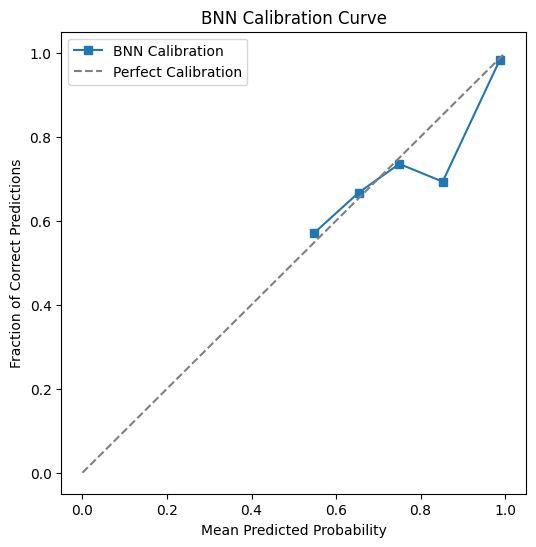

In [ ]:
# run Monte Carlo -dropout and return average probabilities + true labels
def get_mc_dropout_predictions(model, dataloader, num_samples=100):
    # evaluation mode + enable dropout at inference (train())
    model.eval()
    model.train() 

    all_probs = []
    all_labels = []

    # no gradient updates
    with torch.no_grad():
        for inputs, labels in dataloader:
            batch_probs = []
            
            # run multiple "forward passes" -> monte carlo sampling
            for _ in range(num_samples): 
                outputs = model(inputs)  
                probs = torch.softmax(outputs, dim=1).cpu().numpy()  
                batch_probs.append(probs)

            # calculate mean probability
            avg_probs = np.mean(batch_probs, axis=0)
            all_probs.append(avg_probs)
            all_labels.append(labels.cpu().numpy())

    return np.vstack(all_probs), np.hstack(all_labels)

# helper function to actually plot the calibration curve
def plot_calibration_curve(model, dataloader, num_samples=100, bins=10):
    # see function above 
    probs, labels = get_mc_dropout_predictions(model, dataloader, num_samples)
    
    # take max probability and corresponding true class
    confidences = np.max(probs, axis=1)  
    predictions = np.argmax(probs, axis=1) 

    # correct predictions 
    correct = (predictions == labels).astype(int) 
    
    # compute calibration curve
    fraction_of_positives, mean_predicted_value = calibration_curve(correct, confidences, n_bins=bins)
    
    # plot the calibration curve
    plt.figure(figsize=(6,6))
    plt.plot(mean_predicted_value, fraction_of_positives, "s-", label="BNN Calibration")
    plt.plot([0,1], [0,1], "--", color="gray", label="Perfect Calibration")
    
    plt.xlabel("Mean Predicted Probability")
    plt.ylabel("Fraction of Correct Predictions")
    plt.title("BNN Calibration Curve")
    plt.legend()
    plt.show()

# use current model and test data to create a calibration curve, adjust samples if needed
# might be a good idea to use same amount of samples as in training (mc_samples)
plot_calibration_curve(model, test_loader, num_samples=100)

# calibration curve interpretation:

# perfect calibration = if the curve follows this line, the model is well calibrated
# OVERCONFIDENT => if the curve is BELOW the diagonal, the model assigns higher probabilities than it should
# UNDERCONFIDENT => if the curve is ABOVE the diagonal, the model undershoots it's probability estimations

# how to optimize:
# if overconfident => if categorical classification, try Temperature/Platt-scaling, 
# for other models, adjust hyperparameters, model structure etc.

# if underconfident: get more data or add more regularization

# IF THE LINE IS COMPLETELY MISALIGNED:
# increase MC samples to improve uncertainty estimation

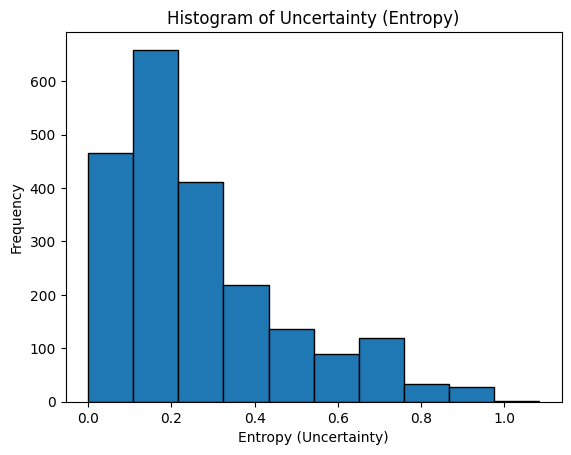

In [ ]:
# convert to a numpy array for easier manipulation
y_pred_probs = np.array(y_pred_probs)

# calculate entropy for each sample (sum of -p * log(p) for each class)
entropy = -np.sum(y_pred_probs * np.log(y_pred_probs + 1e-10), axis=1)  # Add small epsilon to avoid log(0)

# plot histogram of entropy
plt.hist(entropy, bins=10, edgecolor='k')
plt.xlabel('Entropy (Uncertainty)')
plt.ylabel('Frequency')
plt.title('Histogram of Uncertainty (Entropy)')
plt.show()

# in optimal case, entropy is stacked on the left side
# with only a small number of uncertainty on the high end

# this particular example is a very bad result, most uncertainty
# is in the high end

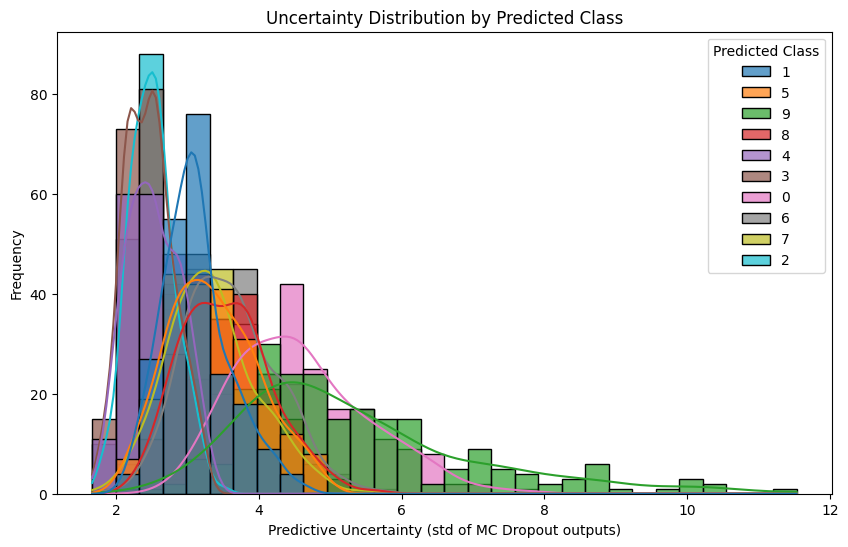

In [ ]:
# store predictive uncertainties and predicted classes
uncertainties = []
predicted_classes = []

# perform inference and collect uncertainty metrics for each sample
with torch.no_grad():
    for X_batch, _ in test_loader:
        outputs_list = [model(X_batch, mc_dropout=True) for _ in range(10)]
        outputs_stack = torch.stack(outputs_list)  
        
        # compute mean and std (uncertainty) of predictions
        outputs_mean = outputs_stack.mean(dim=0)  
        outputs_std = outputs_stack.std(dim=0)  

        # convert to probabilities
        probs = torch.softmax(outputs_mean, dim=1).cpu().numpy()
        
        # compute uncertainty as standard deviation of probabilities
        uncertainty_per_sample = outputs_std.mean(dim=1).cpu().numpy()  # Averaged across classes
        
        # get predicted class
        preds = np.argmax(probs, axis=1)

        # store results
        uncertainties.extend(uncertainty_per_sample)
        predicted_classes.extend(preds)

# convert to pandas DataFrame for easier plotting
plot_df = pd.DataFrame({"Uncertainty": uncertainties, "Predicted Class": predicted_classes})

# Convert predicted class to categorical
plot_df["Predicted Class"] = plot_df["Predicted Class"].astype(str)

# plot uncertainty distributions by class
plt.figure(figsize=(10, 6))
sns.histplot(data=plot_df, x="Uncertainty", hue="Predicted Class", bins=30, kde=True, palette="tab10", alpha=0.7, legend=True)
plt.xlabel("Predictive Uncertainty (std of MC Dropout outputs)")
plt.ylabel("Frequency")
plt.title("Uncertainty Distribution by Predicted Class")

# quick/dirty fix to avoid the bug with numeric labels for matplotlib
handles, labels = plt.gca().get_legend_handles_labels()
if labels: 
    # add prefix "Class" for each target label (which is a number), e.g. Class 3
    class_labels = [f"Class {l}" for l in labels]  
    plt.legend(handles, class_labels, title="Predicted Class", bbox_to_anchor=(1.05, 1), loc='upper left')


plt.show()

# might be a good idea to compare this result to confusion matrix to see if the categories match

In [ ]:
#uncertainty for each predicted class from 0 to 9. Classes like 2 (light blue), 0 (black), and 3 (purple) have low uncertainty (around 2–4), meaning the model is confident. Classes like 8 (green), 7 (yellow), and 5 (orange) show wider uncertainty (up to 10+), meaning the model is less sure about them.

### Use the model in practice (inference)

In [ ]:
# you can adjust the mc_samples to improve uncertainty estimation, 
# values in the range 50-100 are usually ok, sometimes even more
def process_single_row_with_uncertainty(model, input_row, device, mc_samples=50):
    # set model to evaluation mode
    model.eval()  

    # convert input row to a tensor and reshape it to match model input
    input_tensor = torch.tensor(input_row, dtype=torch.float32).unsqueeze(0).to(device)  

    # disable gradient updates, since we are not training at the moment
    with torch.no_grad():  
        # perform multiple forward passes with dropout enabled
        outputs_list = [model(input_tensor, mc_dropout=True) for _ in range(mc_samples)]
        outputs_stack = torch.stack(outputs_list) 

        # compute mean prediction (expected class probabilities)
        outputs_mean = outputs_stack.mean(dim=0).squeeze()  

        # compute uncertainty (standard deviation of probabilities across MC samples)
        outputs_std = outputs_stack.std(dim=0).squeeze()

        # convert logits to probabilities using softmax
        pred_probs = torch.softmax(outputs_mean, dim=0).cpu().numpy()
        pred_uncertainty = outputs_std.cpu().numpy() 

        # predicted class is the one with the highest probability
        pred_class = np.argmax(pred_probs)

    return pred_class, pred_probs, pred_uncertainty

# add your support variable values here for a new row
tester_row = {
    "fixed acidity":            7.4000,
    "volatile acidity":         0.7000,
    "citric acid":              0.0000,
    "residual sugar":           1.9000,
    "chlorides":                0.0760,
    "free sulfur dioxide":     11.0000,
    "total sulfur dioxide":    34.0000,
    "density":                  0.9978,
    "pH":                       3.5100,
    "sulphates":                0.5600,
    "alcohol":                  9.4000
}

# convert to pandas-format
tester_row = pd.DataFrame([tester_row])

# get values and scale with same scaler as original training data
input_row = tester_row.values[0]
input_row = scaler.transform([input_row])
input_row = list(input_row[0])

# run the model and get predictions, probabilities and uncertainties
pred_class, pred_probs, pred_uncertainty = process_single_row_with_uncertainty(model, input_row, torch.device('cpu'))

# set print options to suppress scientific notation
np.set_printoptions(suppress=True)

# see the results
print(f"Predicted Class: {pred_class}")
print(f"Predicted Probabilities: {pred_probs}")
print(f"Predictive Uncertainty (per class): {pred_uncertainty}")
print(f"Predicted Class name (original wine quality): {categories[pred_class]}")


# uncertainty is not a percentage, the value can be anything 0 - 150, or even more

ValueError: X has 11 features, but StandardScaler is expecting 16 features as input.